# Análise de População - Censo 2010 x 2022

Seguindo o passo a passo pedido.

### 3 - Instalar bibliotecas

In [ ]:
# pip install pandas openpyxl matplotlib seaborn


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### 4 - Ler a tabela

In [ ]:
df = pd.read_excel("dados/CD2022_Populacao_2010_Compatibilizada_20231222.xlsx", sheet_name="Municípios", header=2)

# tirar linhas vazias/notas do final da planilha
df = df.dropna(subset=["UF", "COD. MUNIC"])

col_2010 = "População 2010 (Alterações de Limites até 2022)1"
col_2022 = "População Censo 2022"

df.head()


### 5 - Tabela agregada por estado (GROUP BY)

In [ ]:
pop_estado = (
    df.groupby(["COD. UF", "UF"], as_index=False)
      .agg(
          populacao_2010=(col_2010, "sum"),
          populacao_2022=(col_2022, "sum"),
      )
)

pop_estado


### 6 - Ordenar pela população que mais cresceu (diferença)

In [ ]:
pop_estado["diferenca"] = pop_estado["populacao_2022"] - pop_estado["populacao_2010"]
pop_estado = pop_estado.sort_values("diferenca", ascending=False)

pop_estado


### 7 - Salvar tabela por estado em CSV

In [ ]:
pop_estado.to_csv(r"saidas/populacao_por_estado.csv", sep=";")


### 8 - Agora por município

In [ ]:
pop_municipio = df[["COD. UF", "UF", "COD. MUNIC", "NOME DO MUNICÍPIO", col_2010, col_2022]]

pop_municipio.head()


### 9 - Ordenar município pela população que mais cresceu

In [ ]:
pop_municipio["diferenca"] = pop_municipio[col_2022] - pop_municipio[col_2010]
pop_municipio = pop_municipio.sort_values("diferenca", ascending=False)

pop_municipio.head(10)


### 10 - Salvar tabela por município em CSV

In [ ]:
pop_municipio.to_csv(r"saidas/populacao_por_municipio.csv", sep=";")


### 11 - Gráfico dos estados que mais cresceram

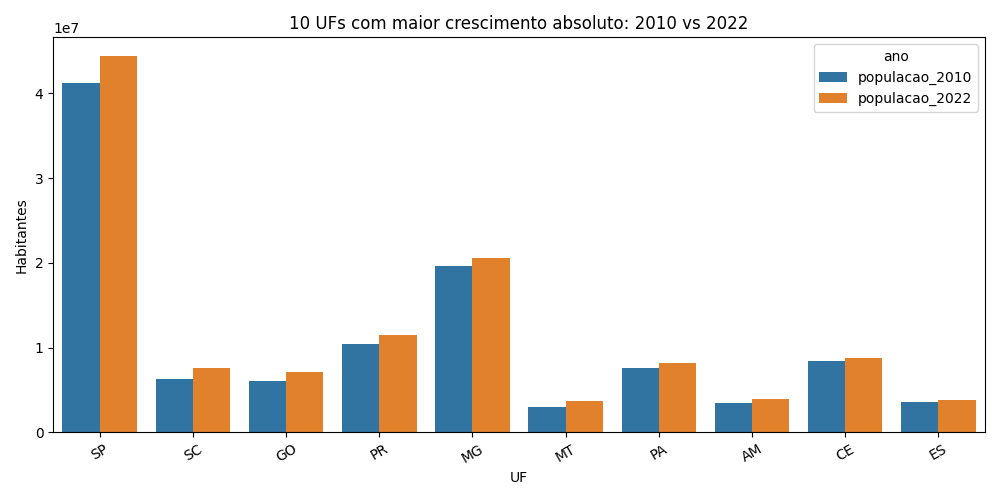

In [ ]:
top = pop_estado.head(10).melt(
    id_vars="UF",
    value_vars=["populacao_2010", "populacao_2022"],
    var_name="ano",
    value_name="populacao",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top, x="UF", y="populacao", hue="ano", ax=ax)
ax.set_title("10 UFs com maior crescimento absoluto: 2010 vs 2022")
ax.set_ylabel("Habitantes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("grafico_top10_estados.png")
plt.show()
